In [9]:
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt

fv = 36  # Fundamental Value

def simulate_market_with_volume(bids, asks):
    """
    Simulates market matching of bids and asks. 
    The last transaction price is determined as the price at which demand meets supply.
    """
    matched_bids = sorted(bids, key=lambda x: x[0], reverse=True)
    matched_asks = sorted(asks, key=lambda x: x[0])

    final_price = None

    while matched_bids and matched_asks:
        best_bid_price, best_bid_volume = matched_bids[0]
        best_ask_price, best_ask_volume = matched_asks[0]

        if best_bid_price >= best_ask_price:
            transaction_price = best_ask_price
            traded_volume = min(best_bid_volume, best_ask_volume)
            final_price = transaction_price

            best_bid_volume -= traded_volume
            best_ask_volume -= traded_volume

            if best_bid_volume == 0:
                matched_bids.pop(0)
            else:
                matched_bids[0] = (best_bid_price, best_bid_volume)

            if best_ask_volume == 0:
                matched_asks.pop(0)
            else:
                matched_asks[0] = (best_ask_price, best_ask_volume)
        else:
            break

    return final_price


def find_best_distribution(close_price, prev_close, second_prev_close, volume):
    """
    Finds the best distribution of Fundamental, Cyclical, and Momentum traders
    that results in a simulated closing price closest to the actual close.
    """
    distributions = np.arange(0.00, 1.02, 0.02)
    weight_combinations = list(itertools.product(distributions, repeat=3))  # Three trading types

    # Define trading type bids and asks
    bids = [
        close_price + 0.2 if close_price < fv else None,  # Fundamental Trader
        close_price + 0.2,  # Cyclical Trader
        close_price + (prev_close - second_prev_close) if second_prev_close < prev_close else None  # Momentum Trader
    ]

    asks = [
        close_price - 0.2 if close_price > fv else None,  # Fundamental Trader
        close_price - 0.2,  # Cyclical Trader
        close_price - (second_prev_close - prev_close) if second_prev_close >= prev_close else None  # Momentum Trader
    ]

    best_closest_price = float('inf')
    best_distribution = None

    # Find best distribution
    for weights in weight_combinations:
        bid_volumes = [w * volume for w in weights if w > 0]
        ask_volumes = [w * volume for w in weights if w > 0]
        
        market_bids = [(b, v) for b, v in zip(bids, bid_volumes) if b is not None]
        market_asks = [(a, v) for a, v in zip(asks, ask_volumes) if a is not None]

        simulated_price = simulate_market_with_volume(market_bids, market_asks)

        if simulated_price is not None and abs(simulated_price - close_price) <= abs(best_closest_price - close_price):
            best_closest_price = simulated_price
            best_distribution = weights

    return best_distribution, best_closest_price


def run_rational_speculator_backtest(historical_data, shock_std=50, increment=0.2):
    """
    Runs the trading type model with rational speculator acting as the market mechanism.
    The model:
      - Identifies the best trading type distribution daily
      - Uses that distribution to simulate the next day's price
      - Adjusts bids/asks based on rational speculator's forecast.
    """
    simulated_data = []
    last_close = historical_data.iloc[0]['Close']
    last_volume = historical_data.iloc[0]['Volume']

    for i in range(1, len(historical_data)):
        date = historical_data.index[i]
        real_close = historical_data.iloc[i]['Close']
        daily_volume = historical_data.iloc[i]['Volume']

        # Step 1: Find best trader distribution for the previous day
        best_distribution, simulated_price = find_best_distribution(
            last_close, last_close, last_close, last_volume
        )

        # Step 2: Rational Speculator's Forecasting Mechanism
        forecasted_price = simulated_price

        # Step 3: Rational Speculator Bids & Asks
        rational_bid = forecasted_price + increment if real_close < forecasted_price else None
        rational_ask = forecasted_price - increment if real_close > forecasted_price else None

        # Store results
        simulated_data.append({
            'Date': date,
            'Real Close': real_close,
            'Simulated Close': simulated_price,
            'Rational Forecast': forecasted_price,
            'Rational Bid': rational_bid,
            'Rational Ask': rational_ask,
            'Best Distribution': best_distribution
        })

        # Update for next iteration
        last_close = simulated_price
        last_volume = daily_volume

    return pd.DataFrame(simulated_data)


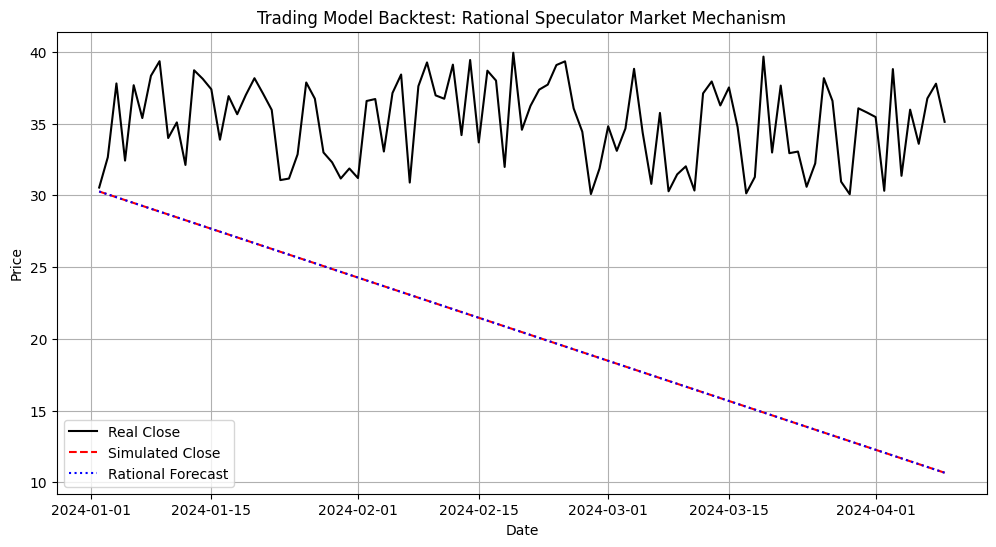

In [10]:
# Generate example historical data (Closing Prices & Volume)
historical_data = pd.DataFrame({
    'Close': np.random.uniform(30, 40, 100),  # Simulated closing prices
    'Volume': np.random.randint(1000, 5000, 100)  # Randomized volumes
}, index=pd.date_range(start='2024-01-01', periods=100))

# Run the backtest with rational speculator as market mechanism
df_results = run_rational_speculator_backtest(historical_data)

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(df_results['Date'], df_results['Real Close'], label="Real Close", color='black')
plt.plot(df_results['Date'], df_results['Simulated Close'], label="Simulated Close", linestyle="--", color='red')
plt.plot(df_results['Date'], df_results['Rational Forecast'], label="Rational Forecast", linestyle=":", color='blue')
plt.legend()
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Trading Model Backtest: Rational Speculator Market Mechanism")
plt.grid(True)
plt.show()


What the flip is going wrong here? After checking the tuples from the trading function (weight, bid/ask) there shouldn't be to many error sources left 